On a un pb de régression

modèles à essayer : régression linéaire, KNN, forets aléatoires, xgboost, réseaux de neuronnes
(notamment des RNN car séries temporelles)

mélangent de modèles ? 


QUESTIONNEMENT : 

- prédire les deux sorties à la fois ou les deux séparément ?
La question se pose surtout
pour les réseaux de neuronnes : des études ont montré que dans certains cas (je me rappelle plus lesquels)
cela améliore la performance car cela oblige le réseau de neuronnes à comprendre dans la profondeur les
données

- Quel retard choisir ?? 
Peut être choisir par validation croisée ? 

- peu de données ... 1000 observations --> attention au surapprentissage 








On importe les modules et packages nécessaires pour le on fonctionnement du code (peut être faire un 
requirements.txt puis pip install -r requirements.txt)

In [228]:
#%pip install statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import statsmodels.api as sm

chargement des données et première exploration des données

['Utr', 'Ytr', 'Uts1', 'Uts2']
Utr shape: (1000, 2)
Ytr shape: (1000, 2)
Uts shape: (1000, 2)
Uts2 shape: (1000, 2)
       Utr0      Utr1
0  1.225856  0.043213
1 -0.379083 -0.411898
2  0.683140 -0.921644
3  0.374853 -0.572683
4  0.256665 -0.760764
       Ytr0      Ytr1
0  0.000000  0.000000
1  0.042170  0.720120
2 -0.016521 -0.222306
3 -0.235810  0.020866
4 -0.080339 -0.352666


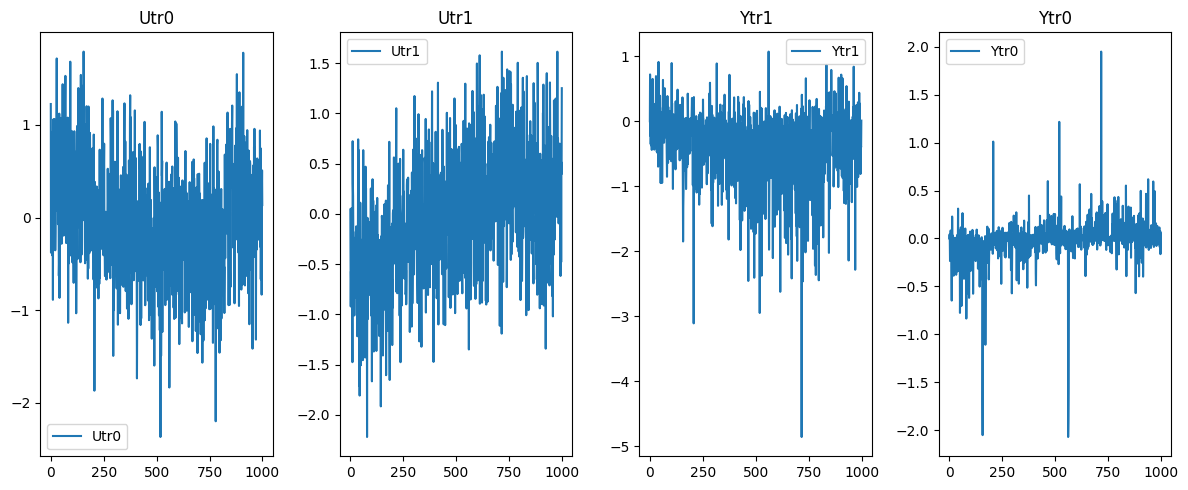

In [229]:
# Charger le fichier
data = np.load('StudentdataNARX.npz')

# Voir la liste des variables
print(data.files)

Utr = data['Utr']
Ytr = data['Ytr']
Uts = data['Uts1']
Uts2 = data['Uts2']

print("Utr shape:", Utr.shape)
print("Ytr shape:", Ytr.shape)
print("Uts shape:", Uts.shape)
print("Uts2 shape:", Uts2.shape)



# transformer les données de train en dataframe pandas
X = pd.DataFrame(Utr, columns=[f'Utr{i}' for i in range(Utr.shape[1])])
Y = pd.DataFrame(Ytr, columns=[f'Ytr{i}' for i in range(Ytr.shape[1])])
print(X.head(5))
print(Y.head(5))



figure, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[0].plot(X['Utr0'], label='Utr0')
axes[0].set_title('Utr0')
axes[0].legend()
axes[1].plot(X['Utr1'], label='Utr1')
axes[1].set_title('Utr1')
axes[1].legend()
axes[2].plot(Y['Ytr1'], label='Ytr1')
axes[2].set_title('Ytr1')
axes[2].legend()
axes[3].plot(Y['Ytr0'], label='Ytr0')
axes[3].set_title('Ytr0')
axes[3].legend()
plt.tight_layout()
plt.show()


- Création des pilotes

**PILOTE NARX1**

          u
0  0.000000
1  0.993428
2 -0.276529
3  1.295377
4  3.046060
shape U (1001, 1)
0    0.000000
1    0.993428
2   -0.276529
3    1.295377
4    3.046060
5   -0.468307
6   -0.468274
7    3.158426
8    1.534869
9   -0.938949
Name: u, dtype: float64
         y1        y2
0  0.000000  0.000000
1  0.279871  0.184927
2  0.195801  0.345530
3  0.868832  0.357879
4  0.619133  1.247585
5  1.725684  1.516910
6  2.799638  1.243454
7  1.979916  0.966679
8  1.651441  2.988558
9  1.453022  2.196904
shape Y (1001, 2)
shape U (1001, 1)


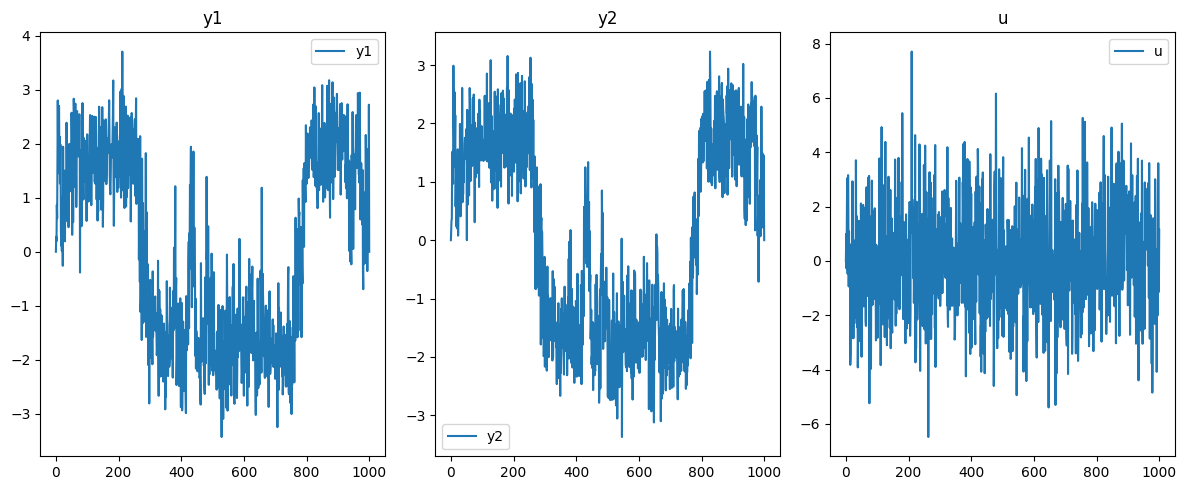

In [230]:

#simule NARX1 en pouvant choisir longueur (N) et variance du bruit
# dois etre mis en fonction car demande d'être flexible
def simulate_Narx1(n_points,sigma_noise,seed=42):

    np.random.seed(seed) # pour la reproductibilité

    # création des pilotes donnés dans l'énoncé
    # génération de U
    U_Narx1 = pd.DataFrame(np.zeros((n_points+1,1)),columns=['u']) #permet d'ajouter instant zéro pour y(0)=u(0)=0
    Y_Narx1 = pd.DataFrame(np.zeros((n_points+1,2)),columns=['y1', 'y2'])

    # générer U qui suit une distribution normale (moyenne 0, écart-type 2) : mon choix arbitraire
    U_Narx1.loc[1:,'u'] = np.random.normal(0, 2, size=n_points) #évite 4 lignes en plus
    # n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
    # on change sa valeur en 0 après
    #U_Narx1.loc[0, 'u'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx1.loc[1, 'u'] = 0 # u0 = 0

    print(U_Narx1.head())
    print("shape U", U_Narx1.shape)
    print(U_Narx1['u'].head(10))


    # génération de Y
    # y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
    # à prédire (exo principal du projet)
    y1_0 = 0
    y2_0 = 0
    # y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
    #y1_minus_1 = 0
    #y2_minus_1 = 0
    #Y_Narx1.loc[0] = [y1_minus_1, y2_minus_1]
    Y_Narx1.loc[0] = [y1_0, y2_0]

    for i in range(1, n_points):

        # les indices seront réglés après la boucle
        y1_k2= Y_Narx1['y1'].iloc[i-2] if i-2>=0 else 0 #car iloc def de 0 à length-1 donc quand -1 pas bon
        y2_k2= Y_Narx1['y2'].iloc[i-2] if i-2>=0 else 0
        u_k2=U_Narx1['u'].iloc[i-2] if i-2>=0 else 0

        # deux formules données dans l'énoncé
        y1_i = 0.5 * y2_k2 + np.sin(Y_Narx1['y2'].iloc[i-1]) + 0.3 * u_k2 + np.random.normal(loc=0, scale=sigma_noise)
        y2_i = 0.5 * y1_k2 + np.sin(Y_Narx1['y1'].iloc[i-1]) + 0.2 * U_Narx1['u'].iloc[i-1] + np.random.normal(loc=0, scale=sigma_noise)
        Y_Narx1.loc[i] = [y1_i, y2_i]

    # enlever la première ligne qui correspond à y-1 et u-1et qui ont servi à générer les données
    #Y_Narx1 = Y_Narx1.drop(index=0).reset_index(drop=True)
    #U_Narx1 = U_Narx1.drop(index=0).reset_index(drop=True)

    return U_Narx1, Y_Narx1

n_points=1000
#verification si le bruit nulle
sigma1=0.2
U_Narx1, Y_Narx1 = simulate_Narx1(n_points,sigma1)

print(Y_Narx1.head(10))
print("shape Y", Y_Narx1.shape)
print("shape U", U_Narx1.shape)


# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx1['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx1['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx1['u'], label='u')
axes[2].set_title('u')
axes[2].legend()
plt.tight_layout()
plt.show()


- The indices are secured with the condition if i-2 >=0 because iloc(-1) (when k=0) is interpreted as the latest element of the array. However, the problem statement specifies that all previous values are zero. 
- The simulation is encapsulated in a functuion to allow for flexible simulation, enabling the definition of length and nooise variance.

**PILOTE NARX2**

         u1        u2
0  0.000000  0.000000
1  0.000000  0.000000
2  0.000000  0.000000
3  0.049671  0.139936
4 -0.013826  0.092463
shape U (1003, 2)
          y1        y2
0   0.000000  0.000000
1   0.139936  0.049671
2   0.092463 -0.013826
3   0.005948  0.063525
4  -0.064523  0.148138
5   0.069526 -0.023196
6   0.038354 -0.023321
7   0.087558  0.156515
8   0.063429  0.076249
9   0.102379 -0.046501
10 -0.052002  0.053607
11  0.130680 -0.045670
12  0.019743 -0.045961
13  0.206505  0.023732
14 -0.068726 -0.188045
shape Y (1000, 2)
shape U (1000, 2)


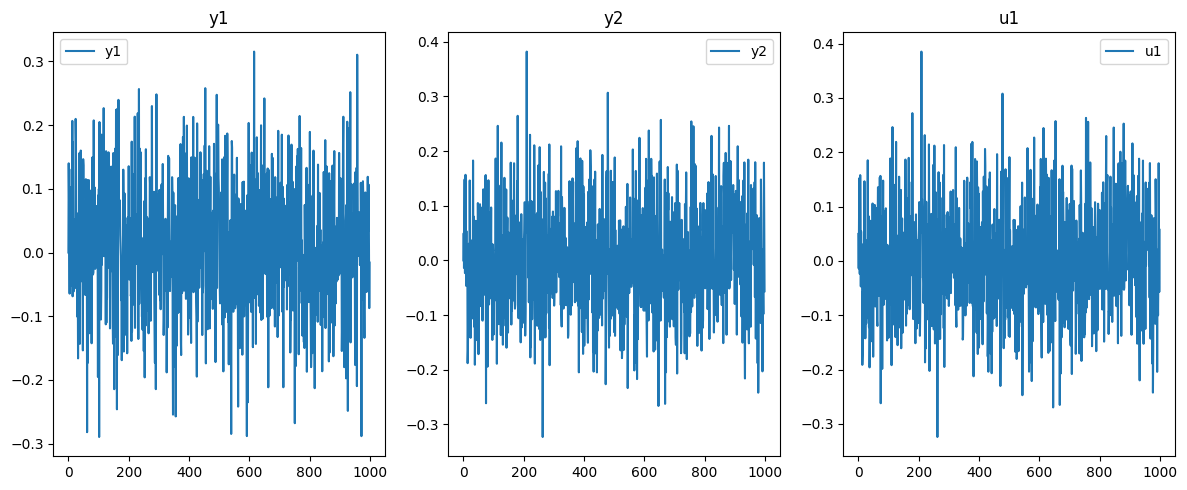

In [231]:
def simulate_Narx2(n_points,sigma_noise,seed=42):

    np.random.seed(seed) # pour la reproductibilité

    # génération de U (deux colonnes cette fois ci u1 et u2)
    U_Narx2 = pd.DataFrame(np.zeros((n_points+3,2)),columns=['u1', 'u2'])
    Y_Narx2 = pd.DataFrame(np.zeros((n_points+3,2)),columns=['y1', 'y2'])
    # générer U qui suit une distribution normale (moyenne 0, écart-type 0.1) : mon choix
    # arbitraire. Pour le coupp si je mets une trop grand evariance il y a explosion des données
    U_Narx2.loc[3:,'u1'] = np.random.normal(0, 0.1, size=n_points)
    U_Narx2.loc[3:,'u2'] = np.random.normal(0, 0.1, size=n_points)
    # n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
    # on change sa valeur en 0 après
    # pa rapport à la génération de Y, pas besoin de remonter à u-2 (cf formules)
    #U_Narx2.loc[0, 'u1'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx2.loc[1, 'u1'] = 0 # u0 = 0
    #U_Narx2.loc[0, 'u2'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx2.loc[1, 'u2'] = 0 # u0 = 0

    print(U_Narx2.head())
    print("shape U", U_Narx2.shape)


    # génération de Y
    # y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
    # à prédire (exo principal du projet)
    y1_0 = 0
    y2_0 = 0
    # y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
    y1_minus_1 = 0
    y2_minus_1 = 0
    y1_minus_2 = 0
    y2_minus_2 = 0
    Y_Narx2.loc[0] = [y1_minus_2, y2_minus_2]
    Y_Narx2.loc[1] = [y1_minus_1, y2_minus_1]
    Y_Narx2.loc[2] = [y1_0, y2_0]
    # Bien faire attention à supprimer les 2 lignes à la fin et pas une seule
    # il faudra peut être les rajouter pour nos stratégies dans le futur (dépend de à quel point on souhaite
    # regarder le futur)


    for k in range(2, n_points+2): # on est décalé à 2 car on a ajouter y-1
        # les indices seront réglés après la boucle
        # deux formules données dans l'énoncé

        y1_k = Y_Narx2.loc[k, 'y1']
        y1_km1 = Y_Narx2.loc[k-1, 'y1']
        y1_km2 = Y_Narx2.loc[k-2, 'y1']

        y2_k = Y_Narx2.loc[k, 'y2']
        y2_km1 = Y_Narx2.loc[k-1, 'y2']
        y2_km2 = Y_Narx2.loc[k-2, 'y2']

        u1_k = U_Narx2.loc[k, 'u1']
        u1_km1 = U_Narx2.loc[k-1, 'u1']

        u2_k = U_Narx2.loc[k, 'u2']
        u2_km1 = U_Narx2.loc[k-1, 'u2']

        # Génération du bruit blanc w
        w1 = np.random.normal(0, sigma_noise)
        w2 = np.random.normal(0, sigma_noise)

        # Formule pour y1(k+1)
        num1 = y1_k * y1_km1 * y1_km2 * (y1_km2 - 1) * u2_km1 + u2_k
        den1 = 1 + y2_km1**2 + y2_km2**2
        y1_plus1 = (num1 / den1) + w1

        # Formule pour y2(k+1)
        num2 = y2_k * y2_km1 * y2_km2 * (y2_km2 - 1) * u1_km1 + u1_k
        den2 = 1 + y1_km1**2 + y1_km2**2
        y2_plus1 = (num2 / den2) + w2

        # Stockage du résultat à l'indice k+1
        Y_Narx2.loc[k+1] = [y1_plus1, y2_plus1]

    # enlever la première ligne qui correspond à y-1 et y-2 et u-1 qui ont servi à générer les données
    Y_Narx2 = Y_Narx2.drop(index=2).reset_index(drop=True)
    Y_Narx2 = Y_Narx2.drop(index=1).reset_index(drop=True)
    Y_Narx2 = Y_Narx2.drop(index=0).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=2).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=1).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=0).reset_index(drop=True)
    return U_Narx2, Y_Narx2
#fait la simu
sigma2=0 #0.02
U_Narx2, Y_Narx2 = simulate_Narx2(n_points, sigma2)

print(Y_Narx2.head(15))
print("shape Y", Y_Narx2.shape)
print("shape U", U_Narx2.shape)

# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx2['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx2['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx2['u1'], label='u1')
axes[2].set_title('u1')
axes[2].legend()
plt.tight_layout()
plt.show()


On a des données très très bruitées .... Utiliser des pilotes très bruités

- Test de nos pilotes : en connaissant la formule de génération qui est linéaire pour Narx1
De plus, pour NArx1, le modèle est linéaire en ses coefficients

On prépare déjà les dataframes, et les jeux de données de tests et train. 
C'est une question qui peut être intéressante à discuter : comment séparer les trains tests ...
J'ai codé 2 méthodes pour faire ça : 
1 méthode qui sépare chronoogiquement les données et une autre qui sépare de manière alternée (peut être plus judicieux poir avoir pls échantillons de val)



In [232]:
# regression linéaire sur NArx1
U_Narx1_reg = pd.DataFrame()
U_Narx1_reg['u'] = U_Narx1['u']
U_Narx1_reg['u_lag1'] = U_Narx1['u'].shift(1) # décalge vers le bas
U_Narx1_reg['u_lag2'] = U_Narx1['u'].shift(2)
U_Narx1_reg['y1_lag1'] = Y_Narx1['y1'].shift(1)
U_Narx1_reg['y1_lag2'] = Y_Narx1['y1'].shift(2)
U_Narx1_reg['y2_lag1'] = Y_Narx1['y2'].shift(1)
U_Narx1_reg['y2_lag2'] = Y_Narx1['y2'].shift(2)
# cf énoncé, les conditions initiales avant l'instant 0 sont nulles

U_Narx1_reg = U_Narx1_reg.fillna(0)

print(U_Narx1_reg.head())
print(Y_Narx1.head())
print("shape U", U_Narx1_reg.shape)


Y_Narx1_reg = pd.DataFrame()
Y_Narx1_reg['y1'] = Y_Narx1['y1'] # Correction : pas besoin de shift, tout est déjà bon
Y_Narx1_reg['y2'] = Y_Narx1['y2']
# afficher la fin du dataframe pour vérifier que le décalage a fonctionné
print(Y_Narx1_reg.tail())
print("shape Y", Y_Narx1_reg.shape)
# dernière ligne de Y est des NA car on a décalé vers le haut, on la supprime car on ne peut
# pas faire de prédiction pour cette ligne. On l'enelve aussi dans U pour garder les mêmes dimensions
Y_Narx1_reg = Y_Narx1_reg.drop(index=Y_Narx1_reg.index[-1]).reset_index(drop=True)
U_Narx1_reg = U_Narx1_reg.drop(index=U_Narx1_reg.index[-1]).reset_index(drop=True)

print(Y_Narx1_reg.tail())
print("shape final Y", Y_Narx1_reg.shape)
print("shape final U", U_Narx1_reg.shape)

# séparation des données en train et test

def split_train_val(X, Y, methode="chronologique", val_size=0.2, train_size_alt=50, val_size_alt=10):
    """
    Split les données en train et val selon la méthode choisie.
    - méthode chronologique : les données de train sont les premières lignes du dataframe, les données de val sont les dernières lignes du dataframe
    - méthode alternée : les données de train et de val sont alternées dans le dataframe, on choisit le nombre de samples de val que l'on veut (ex : 5)
    """
    if methode == "chronologique":
        n_train = int(len(X) * (1 - val_size))
        X_train = X.iloc[:n_train]
        Y_train = Y.iloc[:n_train]
        X_val = X.iloc[n_train:]
        Y_val = Y.iloc[n_train:]

    elif methode == "alternee":
        X_train = []
        Y_train = []
        X_val = []
        Y_val = []
        i = 0
        verif_nb_samples = train_size_alt + val_size_alt # pour avoir des blocs complets de train et val
        while verif_nb_samples <= len(X):
            X_train.append(X.iloc[i:i+train_size_alt])
            Y_train.append(Y.iloc[i:i+train_size_alt])
            X_val.append(X.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            Y_val.append(Y.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            i += train_size_alt + val_size_alt
            verif_nb_samples += train_size_alt + val_size_alt

    return X_train, Y_train, X_val, Y_val

print("split chronologique")
X_train_chrono, Y_train_chrono, X_val_chrono, Y_val_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
print("Shape : ", X_train_chrono.shape, Y_train_chrono.shape, X_val_chrono.shape, Y_val_chrono.shape)
print("split alterné")
X_train_alterne, Y_train_alterne, X_val_alterne, Y_val_alterne = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="alternee", train_size_alt=50, val_size_alt=10)
print("Shape : ", X_train_alterne[-1].shape, Y_train_alterne[-1].shape, X_val_alterne[-1].shape, Y_val_alterne[-1].shape)

          u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1  0.993428  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2 -0.276529  0.993428  0.000000  0.279871  0.000000  0.184927  0.000000
3  1.295377 -0.276529  0.993428  0.195801  0.279871  0.345530  0.184927
4  3.046060  1.295377 -0.276529  0.868832  0.195801  0.357879  0.345530
         y1        y2
0  0.000000  0.000000
1  0.279871  0.184927
2  0.195801  0.345530
3  0.868832  0.357879
4  0.619133  1.247585
shape U (1001, 7)
            y1        y2
996   1.366840  0.216817
997   0.034443  1.195402
998   0.679728  1.452427
999   2.720866  0.653788
1000  0.000000  0.000000
shape Y (1001, 2)
           y1        y2
995  0.742021  0.811771
996  1.366840  0.216817
997  0.034443  1.195402
998  0.679728  1.452427
999  2.720866  0.653788
shape final Y (1000, 2)
shape final U (1000, 7)
split chronologique
Shape :  (800, 7) (800, 2) (200, 7) (2

alignement k -> k+1 pour avoir dynamique temporell en matrice de régression statique (ainsi modèle ne voit pas réponse avant de prédire)

- Travail rapide, pas spécialement important, donne une brève idée 

On use une filter method. Cela nous permet d'évaluer les features indépendamment de l'algorithme de train final. 
On va use le Ranking avec la corrélation de Pearson (Cela nous permet de selectionner les caractéristiques en voyant l'importante de chaque variabke par rapport à la sortie en supossant que relation linéaire). De plus, c'est une technique rapide et efficace car une complexité de O(n) . 

Correlation matrix:
                 u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
u        1.000000 -0.007150 -0.000599  0.010853  0.002756  0.009151  0.020011   
u_lag1  -0.007150  1.000000 -0.006768  0.014410  0.011076  0.003227  0.009661   
u_lag2  -0.000599 -0.006768  1.000000  0.001685  0.014183  0.247658  0.002698   
y1_lag1  0.010853  0.014410  0.001685  1.000000  0.865134  0.851309  0.933764   
y1_lag2  0.002756  0.011076  0.014183  0.865134  1.000000  0.879569  0.851359   
y2_lag1  0.009151  0.003227  0.247658  0.851309  0.879569  1.000000  0.868036   
y2_lag2  0.020011  0.009661  0.002698  0.933764  0.851359  0.868036  1.000000   
y1       0.013465  0.002657  0.335810  0.864617  0.847835  0.933622  0.909435   
y2       0.003009  0.247820  0.010093  0.879585  0.925608  0.867976  0.875385   

               y1        y2  
u        0.013465  0.003009  
u_lag1   0.002657  0.247820  
u_lag2   0.335810  0.010093  
y1_lag1  0.864617  0.879585  
y1_lag2  0.847835 

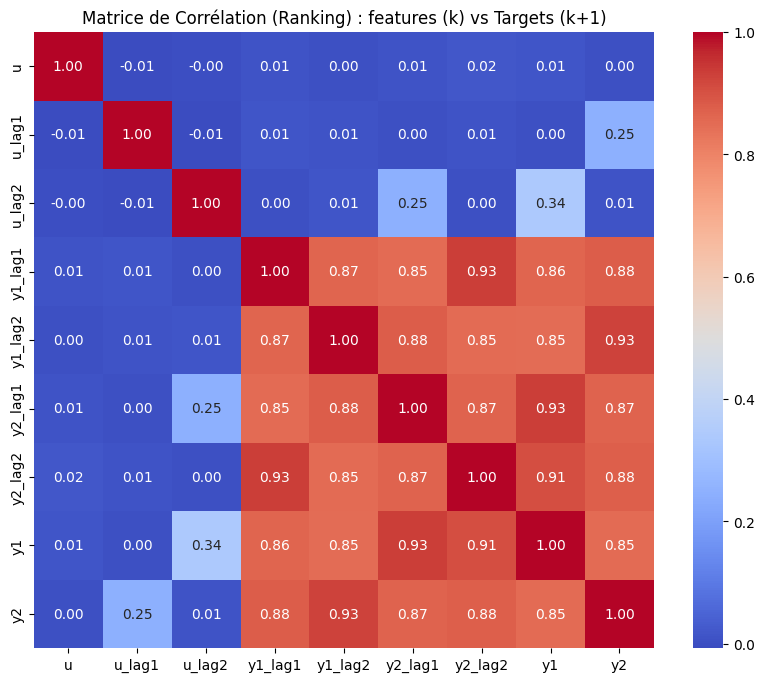

In [233]:
import seaborn as sns
# concaténation feature et cibles
df_analyse = pd.concat([U_Narx1_reg,Y_Narx1_reg], axis=1) #concaténation pour évaluer pertinence par rapport aux cibles
correlation_matrix = df_analyse.corr() #Corrélation de Pearson
print("Correlation matrix:\n", correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation (Ranking) : features (k) vs Targets (k+1)")
plt.show()

- on voit que y1 et y2 sont très corrélés (orange/rouge en bas à droite) -> très couplé
- **Tache 2 a)** on voit que corrélations pour lag2 plutôt élevées (0,6~0,7) donc cela nous permet de voir que l'information à lag2 (y(k-1)) impacte beaucoup à cible (y(k+1)). Il y a 2 pas d'écart entre cible et lag 2 et la corrélation reste forte malgré les deux pas d'écart donc na=2. Avec na=2, on dit au modèle que il faut utiliser y(k) et y(k-1) et donc le modèle aura plus de faciliter à réduire MSE.

Interressant de regarder lag 3 

Correlation matrix avec lag3:
                 u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
u        1.000000 -0.007150 -0.000599  0.010853  0.002756  0.009151  0.020011   
u_lag1  -0.007150  1.000000 -0.006768  0.014410  0.011076  0.003227  0.009661   
u_lag2  -0.000599 -0.006768  1.000000  0.001685  0.014183  0.247658  0.002698   
y1_lag1  0.010853  0.014410  0.001685  1.000000  0.865134  0.851309  0.933764   
y1_lag2  0.002756  0.011076  0.014183  0.865134  1.000000  0.879569  0.851359   
y2_lag1  0.009151  0.003227  0.247658  0.851309  0.879569  1.000000  0.868036   
y2_lag2  0.020011  0.009661  0.002698  0.933764  0.851359  0.868036  1.000000   
u_lag3   0.015160  0.000500 -0.007939  0.333966  0.001024  0.009456  0.246631   
y1_lag3  0.024425  0.002753  0.011083  0.848843  0.865194  0.925670  0.879883   
y2_lag3  0.012722  0.020433  0.009231  0.909668  0.933796  0.875400  0.867970   
y1       0.013465  0.002657  0.335810  0.864617  0.847835  0.933622  0.909435 

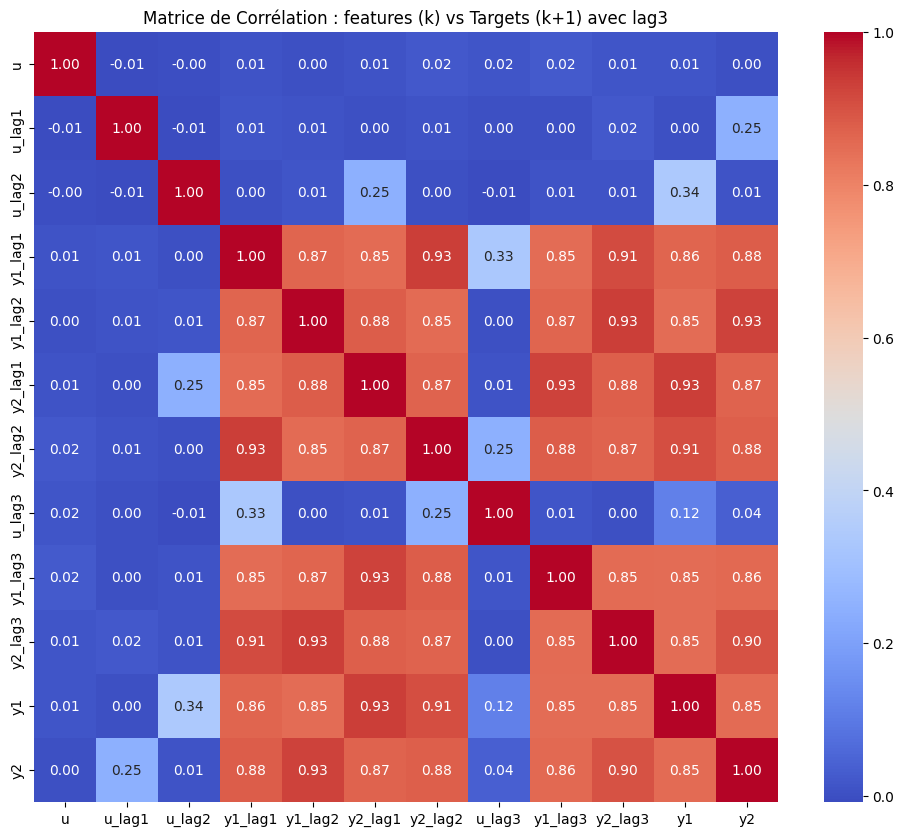

In [234]:
U_Narx1_reg['u_lag3'] = U_Narx1['u'].shift(3)
U_Narx1_reg['y1_lag3'] = Y_Narx1['y1'].shift(3)
U_Narx1_reg['y2_lag3'] = Y_Narx1['y2'].shift(3)

U_Narx1_reg = U_Narx1_reg.fillna(0)

df_analyse_lag3 = pd.concat([U_Narx1_reg,Y_Narx1_reg], axis=1)
correlation_matrix_lag3 = df_analyse_lag3.corr()
print("Correlation matrix avec lag3:\n", correlation_matrix_lag3)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_lag3, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation : features (k) vs Targets (k+1) avec lag3")
plt.show()

Avec Lag 3 on peut voir que l'on a eu une corrélation qui stagne. La différence entre lag 2 et lag 3 est minime donc on conserve **na=2**. Cela nous évite de rendre trop complexe le modèle. 

Donc pour éviter curse of dimensionality, on sélectionne le sous-ensemble {u, u_lag1, u_lag2, y1_lag1, y1_lag2 ...} car maximise sans ajouter de variables inutiles.

Wrapper

In [235]:
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]


100%|██████████| 2/2 [00:00<00:00, 160.69it/s]


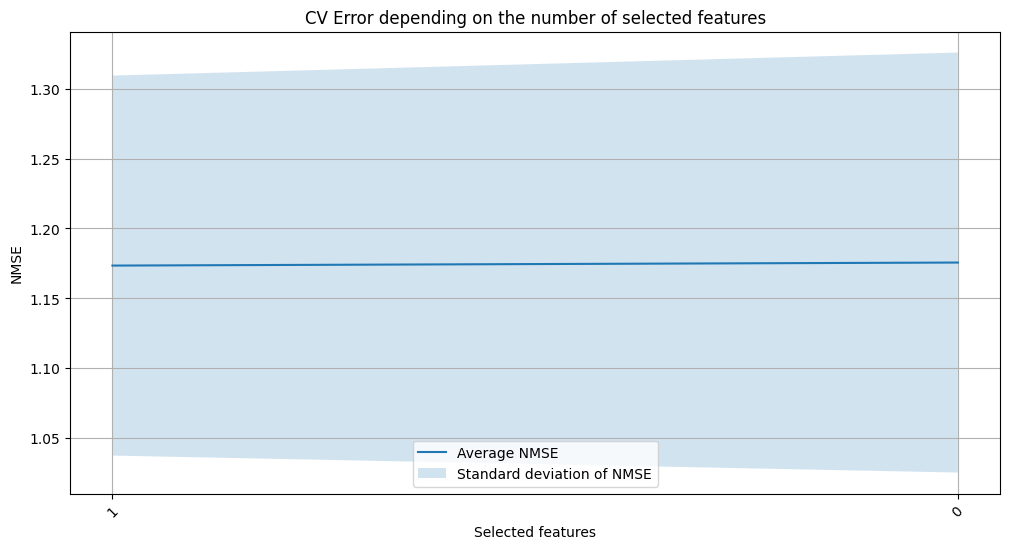

In [236]:
from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

#calcule de NMSE
def nmse(y_original,y_pred):
    mse=mean_squared_error(y_original,y_pred)
    variance=np.var(y_original)
    return mse/variance

#wrapper initialization
selected=[] #indices des variables retenues
CV_err=[] #evolution de erreur moyyenne de cross validation
std_err=[] #evolution ecart type
n=X_train.shape[1]
feature_name=list(X_train.columns)

kf=TimeSeriesSplit(n_splits=5) #pour ne pas mélanger les données car temporelles

#utilise le bloc train pour cross validation
X_fs=X_train
Y_fs=Y_train["Ytr0"].values

#boucle Forward selection (greedy)
for round_i in tqdm(range(n)):
    candidates=list(set(range(n))-set(selected))
    CV_err_temp=[]
    round_fold_errors=[] #permet de stocker les erreurs de chaque fold par candidat

    for c in candidates:
        features_to_include=selected+[c] #on teste ensemble actuel avec un new candidat
        fold_errors=[]

        #cross validation intern sur 5 périodes dif
        for train_index, test_index in kf.split(X_fs):
            X_tr,X_ts=X_fs.iloc[train_index, features_to_include],X_fs.iloc[test_index, features_to_include] #spéaration train et test
            Y_tr,Y_ts=Y_fs[train_index],Y_fs[test_index]

            #baseline
            model = LinearRegression()
            model.fit(X_tr,Y_tr)
            #prediction
            Y_hat_ts=model.predict(X_ts)
            fold_errors.append(nmse(Y_ts,Y_hat_ts))
        #moyenne des erreurs
        CV_err_temp.append(np.mean(fold_errors))
        round_fold_errors.append(fold_errors)

#selection meilleur candidat
    best_index=np.argmin(CV_err_temp)
    best_candidate=candidates[best_index]

    selected.append(best_candidate)
    CV_err.append(CV_err_temp[best_index])
    std_err.append(np.std(round_fold_errors[best_index]))

x=list(range(1,n+1))
errors=np.array(CV_err)
stds=np.array(std_err)
labels=[feature_name[i] for i in selected]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=selected, rotation=45)
plt.legend()
plt.grid("on")
plt.show()


- Regression Linéaire Sur les données Narx1

In [237]:
X_train_narx1_chrono, Y_train_narx1_chrono, X_val_narx1_chrono, Y_val_narx1_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
# on enlève lag3 car dans la forumule théorique, elle n'y est pas
X_train_narx1_chrono = X_train_narx1_chrono.drop(columns=['u_lag3', 'y1_lag3', 'y2_lag3'])
X_val_narx1_chrono = X_val_narx1_chrono.drop(columns  =['u_lag3', 'y1_lag3', 'y2_lag3'])
print("Shape : ", X_train_narx1_chrono.shape, Y_train_narx1_chrono.shape, X_val_narx1_chrono.shape, Y_val_narx1_chrono.shape)

print("columns : ", X_train_narx1_chrono.columns.tolist())
print("head : ", X_train_narx1_chrono.head(5))


model_chrono_lag2 = LinearRegression()
model_chrono_lag2.fit(X_train_narx1_chrono, Y_train_narx1_chrono)
Y_pred_chrono_lag2 = model_chrono_lag2.predict(X_val_narx1_chrono)
nmse_chrono_lag2 = nmse(Y_val_narx1_chrono, Y_pred_chrono_lag2)
print("prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2")
print("NMSE Chronologique lag2 : ", nmse_chrono_lag2)
print("RMSE", np.sqrt(mean_squared_error(Y_val_narx1_chrono, Y_pred_chrono_lag2)))
# afficher les coefficients du modèle
coeff_df_lag2 = pd.DataFrame(model_chrono_lag2.coef_, columns=X_train_narx1_chrono.columns, index=Y_train_narx1_chrono.columns)
print("Coefficients du modèle lag2 :")
print(coeff_df_lag2)
print(f"\nIntercepts : {model_chrono_lag2.intercept_}")


Shape :  (800, 7) (800, 2) (200, 7) (200, 2)
columns :  ['u', 'u_lag1', 'u_lag2', 'y1_lag1', 'y1_lag2', 'y2_lag1', 'y2_lag2']
head :            u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1  0.993428  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2 -0.276529  0.993428  0.000000  0.279871  0.000000  0.184927  0.000000
3  1.295377 -0.276529  0.993428  0.195801  0.279871  0.345530  0.184927
4  3.046060  1.295377 -0.276529  0.868832  0.195801  0.357879  0.345530
prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2
NMSE Chronologique lag2 :  y1    0.234510
y2    0.276443
dtype: float64
RMSE 0.3702032795910861
Coefficients du modèle lag2 :
           u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2
y1  0.000681 -0.002432  0.245622 -0.038628  0.136270  0.269571  0.633912
y2 -0.001272  0.206564 -0.021980  0.142034  0.516066 

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4230: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Ici on a une regression linéaire. Le choix des features a été faite de manière aléatoire dans 
un premier temps (On a pris lag 3). Les résultarts sont cohérents avec les résultats théoriques 
de la formule de Narx1. On retrouve des coefficients correctes devant les termes linéaires. 
Cependant, il est totalement logique qu'un modèle linéaire interprète mal les signaux sinusoidales

Dans la prochaine regression, on va ajouter une colonne en sinus 
Le modele deviendra donc : 
    y1 = 0.5y2(k−2) + sin(y2(k)) + 0.3u(k−2)
    y2 = 0.5y1(k−2) + sin(y1(k-1)) + 0.2u(k-1)



In [238]:
U_Narx1_reg['sin(y2_lag1)'] = np.sin(U_Narx1_reg['y2_lag1'])
U_Narx1_reg['sin(y1_lag1)'] = np.sin(U_Narx1_reg['y1_lag1'])

# on refait la regression linéaire en ajoutant les termes sin(y2_lag1) et sin(y1_lag1) qui sont présents dans les formules théoriques
X_train_narx1_chrono, Y_train_narx1_chrono, X_val_narx1_chrono, Y_val_narx1_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
X_train_narx1_chrono = X_train_narx1_chrono.drop(columns=['u_lag3', 'y1_lag3', 'y2_lag3'])
X_val_narx1_chrono = X_val_narx1_chrono.drop(columns  =['u_lag3', 'y1_lag3', 'y2_lag3'])
print("Shape : ", X_train_narx1_chrono.shape, Y_train_narx1_chrono.shape, X_val_narx1_chrono.shape, Y_val_narx1_chrono.shape)
model_chrono_lag2_sin = LinearRegression()
model_chrono_lag2_sin.fit(X_train_narx1_chrono, Y_train_narx1_chrono)
Y_pred_chrono_lag2_sin = model_chrono_lag2_sin.predict(X_val_narx1_chrono)
nmse_chrono_lag2_sin = nmse(Y_val_narx1_chrono, Y_pred_chrono_lag2_sin)
print("prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2 + les termes sin")
print("NMSE Chronologique lag2 + sin : ", nmse_chrono_lag2_sin)
print("RMSE", np.sqrt(mean_squared_error(Y_val_narx1_chrono, Y_pred_chrono_lag2_sin)))
# afficher les coefficients du modèle
coeff_df_lag2_sin = pd.DataFrame(model_chrono_lag2_sin.coef_, columns=X_train_narx1_chrono.columns, index=Y_train_narx1_chrono.columns)
print("Coefficients du modèle lag2 + sin :")
print(coeff_df_lag2_sin)
print(f"\nIntercepts : {model_chrono_lag2_sin.intercept_}")

Shape :  (800, 9) (800, 2) (200, 9) (200, 2)
prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2 + les termes sin
NMSE Chronologique lag2 + sin :  y1    0.068054
y2    0.080223
dtype: float64
RMSE 0.19942845879475182
Coefficients du modèle lag2 + sin :
           u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
y1  0.000689 -0.002820  0.299444 -0.002285  0.011627 -0.015875  0.498130   
y2  0.003935  0.212014  0.000538 -0.002008  0.494899  0.001476 -0.012241   

    sin(y2_lag1)  sin(y1_lag1)  
y1      1.015357      0.020013  
y2      0.032106      1.001569  

Intercepts : [0.00801951 0.01277341]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4230: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Commen attendu, on a des résultats presque parfaits.

Cependant, on a utilisé les vrais valeurs pour prédire l'état K+1 et non nos prédictions.
Après discussions dans le groupe, on a décidé de commencé par une approche où on utilise nos prédictions 
de manière récursives. 
Il a été aussi été deiscuté de l'idée de faire des prédictions par blocs pour essayer de limiter 
l'exploion de l'erreur.